# 3.1.5 Categories of Classification Algorithms

## Table of Contents
- [Linear Classifiers](#linear-classifiers)
- [Non-linear Classifiers](#non-linear-classifiers)
- [Probabilistic Classifiers](#probabilistic-classifiers)
- [Tree-Based Methods](#tree-based-methods)
- [Distance-Based Methods](#distance-based-methods)
- [Ensemble Methods](#ensemble-methods)
- [Neural Network-Based Classifiers](#neural-network-based-classifiers)

Before we dive into specific classification algorithms, it's helpful to understand the broader categories they fall into. This allows us to better understand their strengths, limitations, and appropriate use cases.

## Linear Classifiers

Linear classifiers separate classes using a linear decision boundary (a line in 2D, a plane in 3D, or a hyperplane in higher dimensions).

**Key Characteristics:**
- Create straight-line decision boundaries
- Fast to train and predict
- Easily interpretable
- Work well when classes are linearly separable

**Examples:**
- **Logistic Regression** (our focus for today)
- Support Vector Machines (with linear kernel)
- Linear Discriminant Analysis (LDA)
- Perceptron

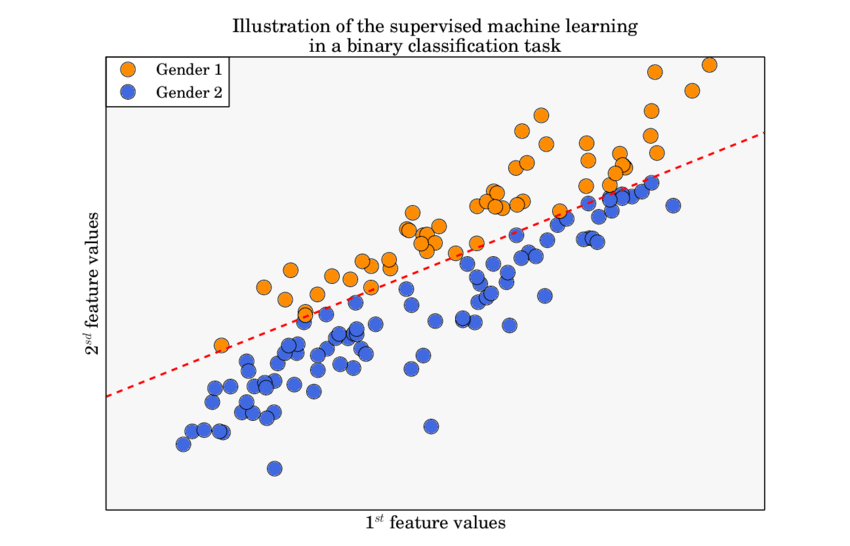

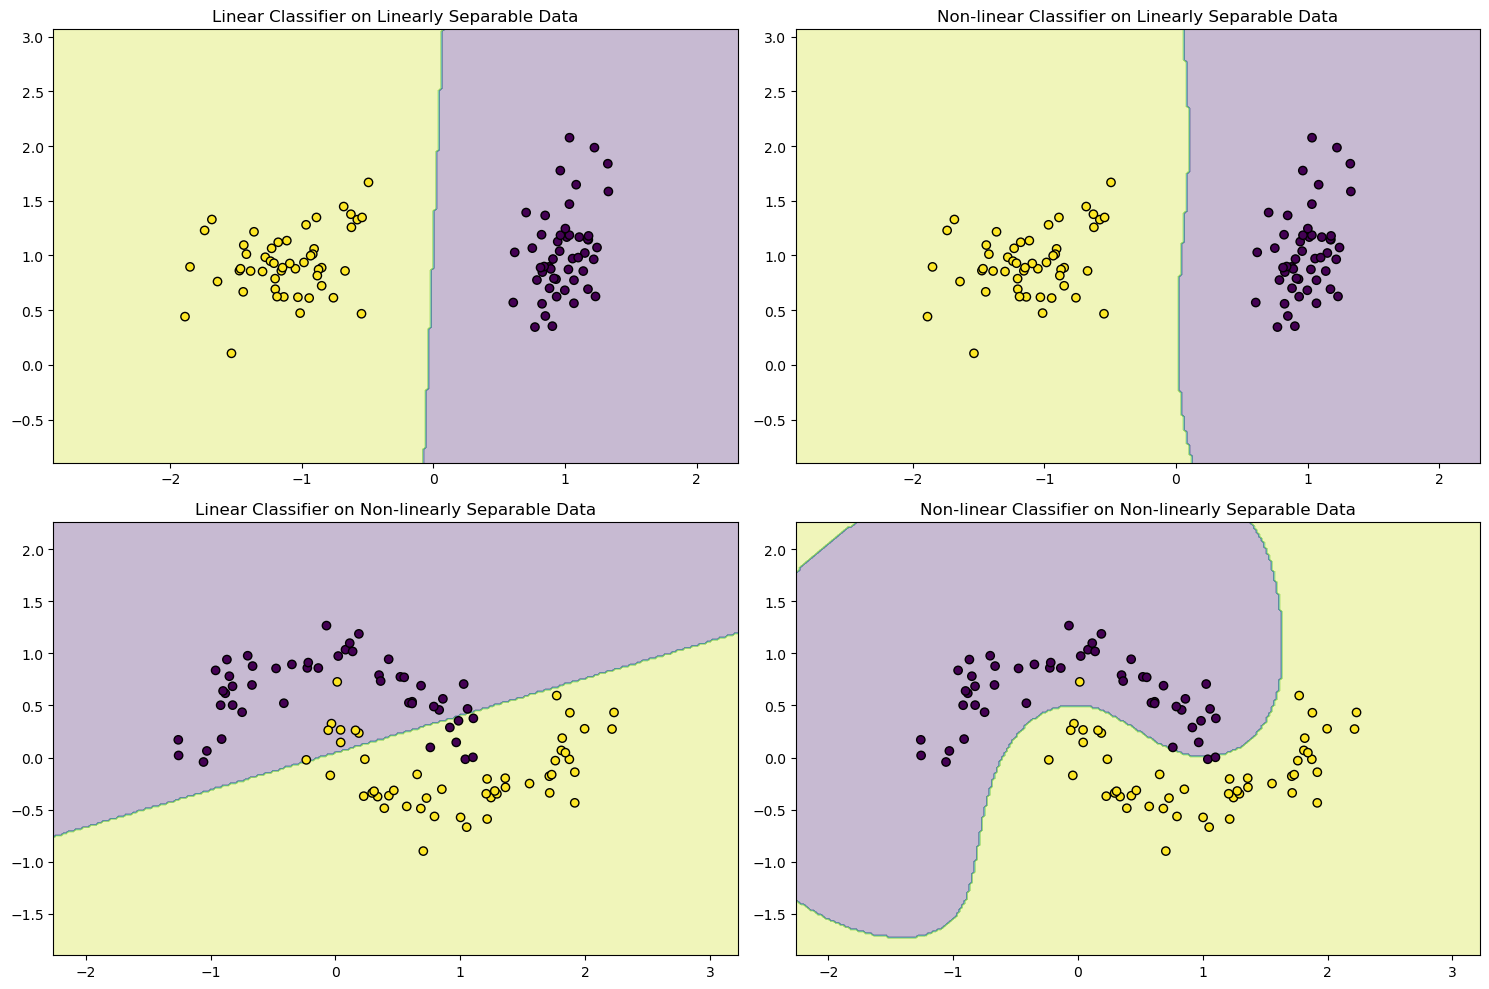

In [2]:
# Simple visualization of linear vs. non-linear decision boundaries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Create datasets
X_linear, y_linear = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                                 n_informative=2, random_state=1, n_clusters_per_class=1)
X_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=1)

# Create classifiers
linear_classifier = LogisticRegression()
nonlinear_classifier = SVC(kernel='rbf')

# Fit on linearly separable data
linear_classifier.fit(X_linear, y_linear)
nonlinear_classifier.fit(X_linear, y_linear)

# Create a mesh to plot in
h = 0.02  # step size in the mesh
x_min, x_max = X_linear[:, 0].min() - 1, X_linear[:, 0].max() + 1
y_min, y_max = X_linear[:, 1].min() - 1, X_linear[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Create figure
plt.figure(figsize=(15, 10))

# Plot linear data with linear classifier
plt.subplot(2, 2, 1)
Z = linear_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, edgecolors='k')
plt.title("Linear Classifier on Linearly Separable Data")

# Plot linear data with non-linear classifier
plt.subplot(2, 2, 2)
Z = nonlinear_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, edgecolors='k')
plt.title("Non-linear Classifier on Linearly Separable Data")

# Fit on non-linearly separable data
linear_classifier.fit(X_moons, y_moons)
nonlinear_classifier.fit(X_moons, y_moons)

# Create a new mesh for moons data
x_min, x_max = X_moons[:, 0].min() - 1, X_moons[:, 0].max() + 1
y_min, y_max = X_moons[:, 1].min() - 1, X_moons[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Plot non-linear data with linear classifier
plt.subplot(2, 2, 3)
Z = linear_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, edgecolors='k')
plt.title("Linear Classifier on Non-linearly Separable Data")

# Plot non-linear data with non-linear classifier
plt.subplot(2, 2, 4)
Z = nonlinear_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, edgecolors='k')
plt.title("Non-linear Classifier on Non-linearly Separable Data")

plt.tight_layout()
plt.show()

<!-- Placeholder for linear vs. non-linear classifier visualization -->
<!-- Figure 1: Comparison of linear and non-linear classifiers on different datasets -->

## Non-linear Classifiers

Non-linear classifiers create decision boundaries that are not straight lines, allowing them to separate classes with more complex relationships.

**Key Characteristics:**
- Create curved or complex decision boundaries
- Can capture more complex patterns in the data
- May require more data and computational resources
- Often less interpretable than linear models

**Examples:**
- Support Vector Machines (with non-linear kernels like RBF, polynomial)
- Decision Trees
- Random Forests
- Neural Networks
- Kernel-based methods

## Probabilistic Classifiers

Probabilistic classifiers in machine learning are models that predict a probability distribution over different classes for a given input, rather than just assigning a single class label. This means they estimate the likelihood of an input belonging to each possible class. Instead of just predicting one category, they provide a measure of confidence for each possible outcome. 

**Key Characteristics:**
- Provide probabilities that indicate confidence in predictions
- Allow for threshold adjustment based on the problem requirements
- Often based on Bayes' theorem or maximum likelihood estimation

**Examples:**
- **Logistic Regression** (also a linear classifier)
- Naive Bayes
- Bayesian Networks
- Gaussian Processes

## Tree-Based Methods

Tree-based classifiers partition the feature space into regions using a series of decisions based on feature values.

At its core, a decision tree asks a sequence of questions (conditions on features) and branches out based on the answers until it reaches a prediction (class label). It's like a flowchart:

* Internal nodes: decision rules (e.g., Age < 30?)

* Leaf nodes: class labels (e.g., Approved, Denied)

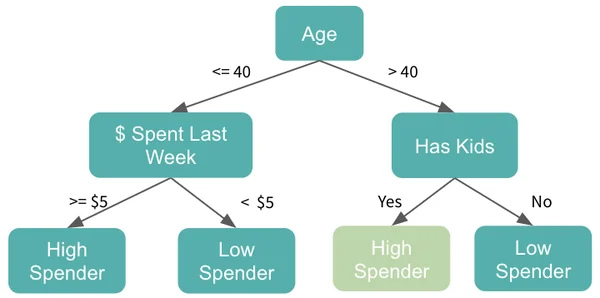

**Key Characteristics:**
- Inherently handle non-linear relationships
- Can capture feature interactions automatically
- Generally robust to outliers and irrelevant features
- Easy to interpret (for single trees)

**Examples:**
- Decision Trees
- Random Forests
- Gradient Boosting Machines (GBM)
- XGBoost, LightGBM, CatBoost

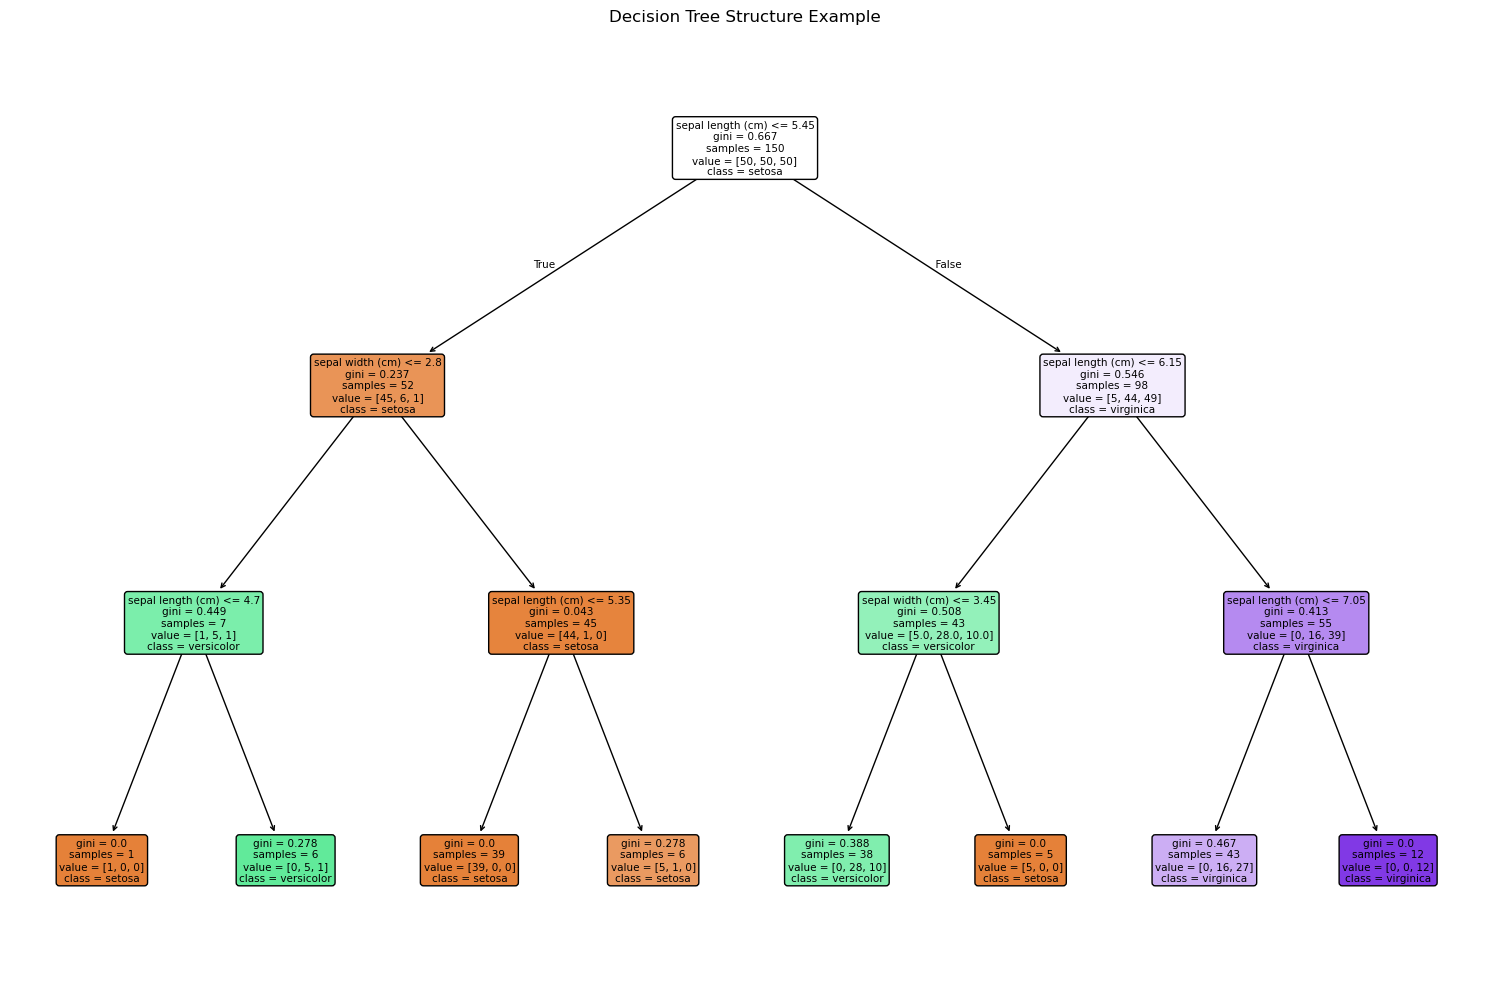

In [3]:
# Simple visualization of a decision tree structure
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris

# Load the iris dataset for a simple example
iris = load_iris()
X = iris.data[:, :2]  # Take only the first two features for visualization
y = iris.target

# Create and train a decision tree
tree_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_classifier.fit(X, y)

# Visualize the tree structure
plt.figure(figsize=(15, 10))
plot_tree(tree_classifier, filled=True, feature_names=iris.feature_names[:2], 
          class_names=iris.target_names, rounded=True)
plt.title("Decision Tree Structure Example")
plt.tight_layout()
plt.show()

<!-- Placeholder for decision tree structure visualization -->
<!-- Figure 2: Visualization of a simple decision tree structure -->

## Distance-Based Methods

Distance-based classifiers are models that classify a data point based on how close it is to other points in the feature space. The distance metric (e.g., Euclidean) plays a key role in determining similarity between samples.

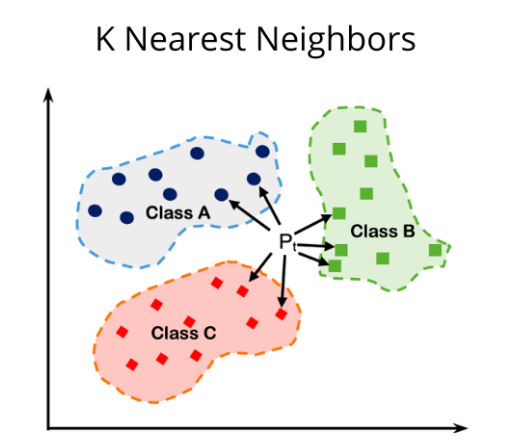

**Key Characteristics:**
- Rely on a distance or similarity metric
- Often simple to implement and understand
- May struggle with high-dimensional data (curse of dimensionality)
- Memory-intensive for large datasets (need to store training data)

**Examples:**
- K-Nearest Neighbors (KNN)
- Support Vector Machines (distance to decision boundary)
- Learning Vector Quantization (LVQ)

## Ensemble Methods

Ensemble methods combine predictions from multiple individual models (often called base learners or weak learners) to produce a stronger and more accurate final prediction. The key idea is: a group of weak models working together can outperform a single strong model.

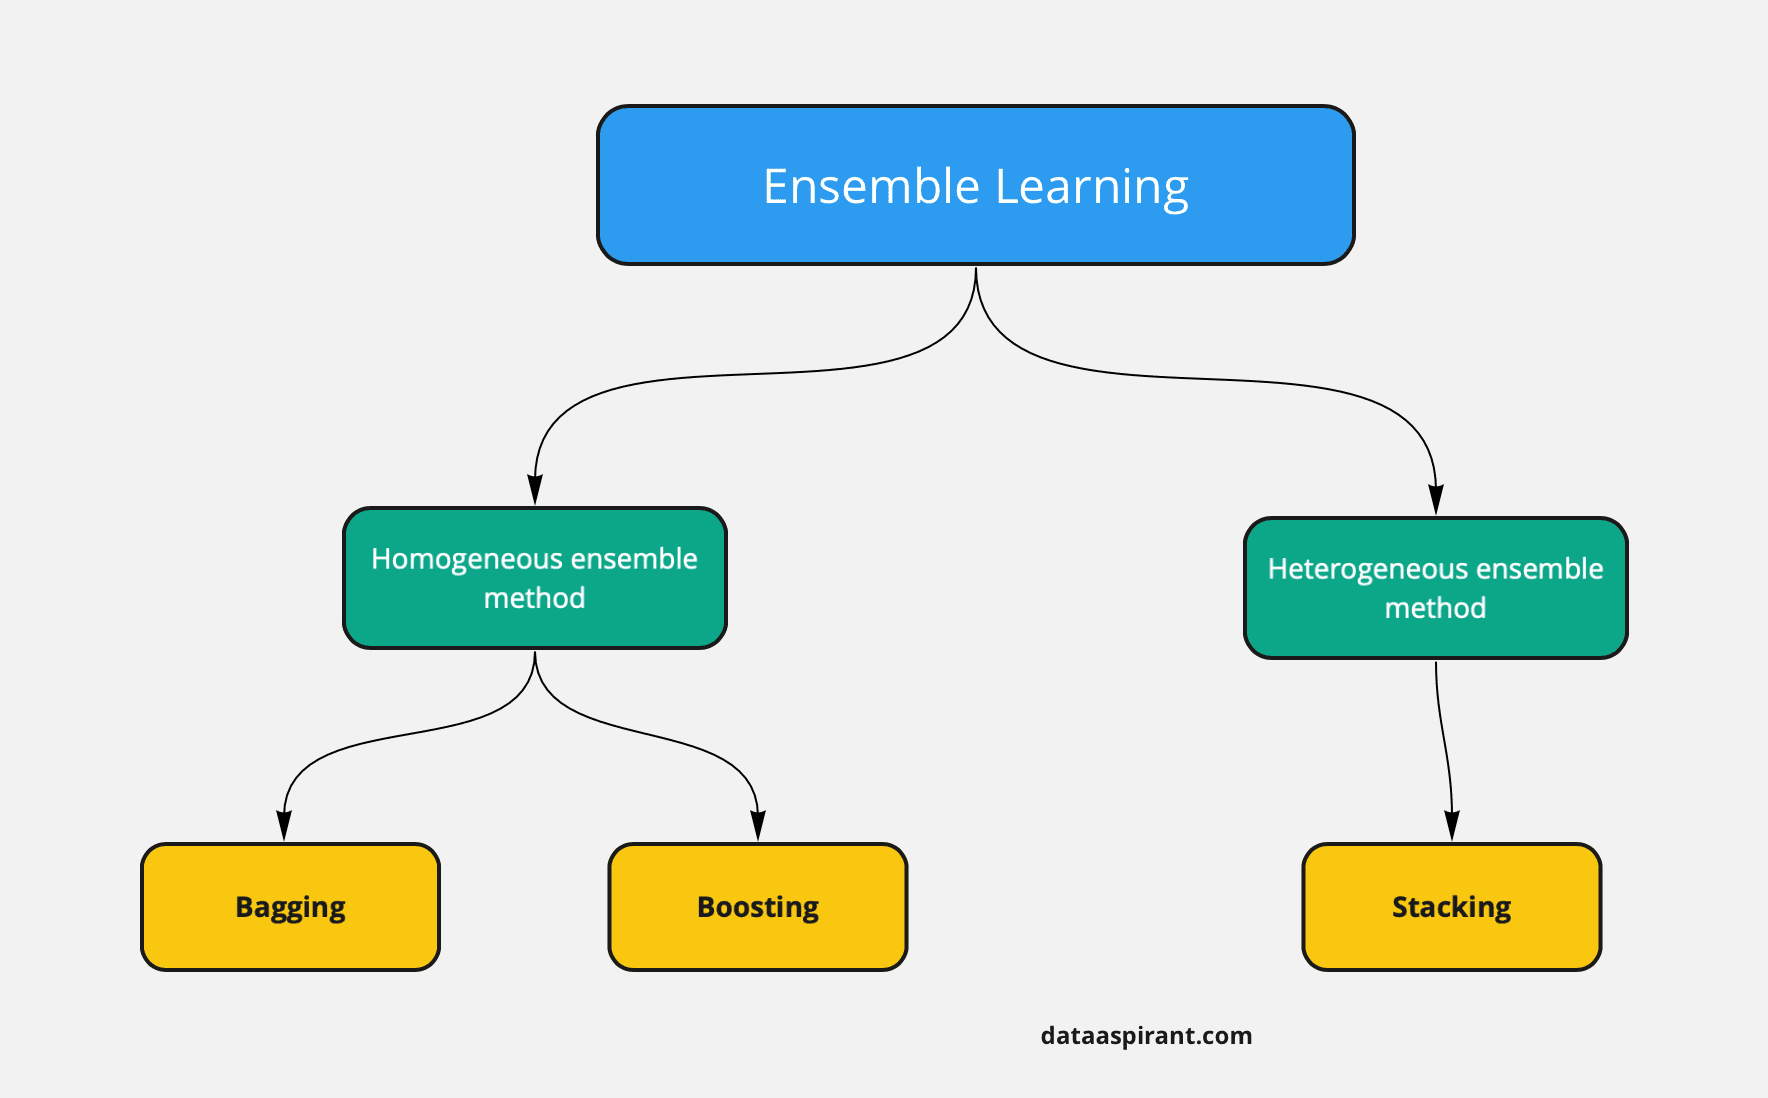

**Key Characteristics:**
- Reduce overfitting by combining multiple models
- Generally achieve better performance than individual models
- Require more computational resources
- Can be built using any type of base classifier

**Examples:**
- Random Forests (ensemble of decision trees)
- Boosting methods (AdaBoost, Gradient Boosting)
- Bagging methods
- Stacking/Blending

## Neural Network-Based Classifiers

Neural networks consist of interconnected layers of neurons that learn to recognize patterns in the data.

**Key Characteristics:**
- Can learn extremely complex patterns
- Require significant amounts of data to train effectively
- Computationally intensive
- Generally less interpretable
- Highly flexible architecture

**Examples:**
- Multi-layer Perceptron (MLP)
- Convolutional Neural Networks (CNN) for image classification
- Recurrent Neural Networks (RNN) for sequence classification
- Transformer-based models

## Choosing the Right Classifier

When selecting a classification algorithm, consider:

1. **Data characteristics:** Size, dimensionality, noise level, class imbalance
2. **Problem requirements:** Interpretability, prediction speed, training time
3. **Performance metrics:** Accuracy, precision, recall, F1-score
4. **Computational constraints:** Memory, processing power

The table below provides a high-level comparison of different classifier categories:

| Category | Interpretability | Training Speed | Prediction Speed | Handles Non-linearity | Works with Small Data | Probabilistic Output |
|----------|-----------------|---------------|-----------------|----------------------|----------------------|---------------------|
| Linear Classifiers | High | Fast | Very Fast | No | Yes | Some (e.g., Logistic Regression) |
| Tree-Based Methods | Medium-High | Medium | Fast | Yes | Yes | Some |
| Distance-Based | High | Very Fast | Slow | Yes | Yes | Some |
| Probabilistic | Medium-High | Fast | Fast | Some | Yes | Yes |
| Ensemble Methods | Low-Medium | Slow | Medium | Yes | Medium | Often |
| Neural Networks | Low | Very Slow | Medium | Yes | No | Yes |


## Why We're Starting with Logistic Regression

Logistic Regression is an excellent first classification algorithm to study because it:

1. Is a **linear classifier** that's relatively easy to understand and implement
2. Provides **probabilistic outputs**, allowing for threshold adjustments
3. Is **computationally efficient** for both training and prediction
4. Offers good **interpretability** through its coefficients
5. Serves as a **strong baseline** for more complex algorithms
6. Has **regularization options** to prevent overfitting
7. Works well for **binary classification** problems (can be extended to multiclass)

In the next section, we'll dive deeper into the theory and implementation of Logistic Regression.